In [ ]:
!pip install transformers[torch] accelerate -U

In [ ]:
!pip install nlpaug

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **PACKAGE**

In [ ]:
import pandas as pd
import numpy as np
import re
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_fscore_support
from imblearn.over_sampling import RandomOverSampler
import nlpaug.augmenter.word as naw

In [ ]:
def clean_text(text):
    # Handle non-string values
    if not isinstance(text, str):
        return ""  # Or any default value you prefer

    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

## **DATA**

In [ ]:
df = pd.read_excel('/content/drive/My Drive/BDC-SatriaData-2024/data_train_selection_normalized_baru_5.xlsx')
df.head()

,cleaning,stemming,label,casefolding,tokenize,normalized,normalized_2,text_clean_normalized
0,kunjungan prabowo ini untuk meresmikan dan men...,"['kunjung', 'prabowo', 'resmi', 'serah', 'proy...",Sumber Daya Alam,kunjungan prabowo ini untuk meresmikan dan men...,"['kunjungan', 'prabowo', 'ini', 'untuk', 'mere...","['kunjungan', 'prabowo', 'ini', 'untuk', 'mere...","['kunjungan', 'prabowo', 'ini', 'untuk', 'mere...",kunjungan prabowo ini untuk meresmikan dan men...
1,anies dapat tepuk tangan meriah saat jadi rekt...,"['anies', 'tepuk', 'tangan', 'riah', 'rektor',...",Politik,anies dapat tepuk tangan meriah saat jadi rekt...,"['anies', 'dapat', 'tepuk', 'tangan', 'meriah'...","['anies', 'dapat', 'tepuk', 'tangan', 'meriah'...","['anies', 'dapat', 'tepuk', 'tangan', 'meriah'...",anies dapat tepuk tangan meriah saat rektor me...
2,emng bener sih pendukung ada yg goblok begitu ...,"['sih', 'dukung', 'bodoh', 'dukung', 'ridwan',...",Demografi,emng bener sih pendukung ada yg goblok begitu ...,"['emng', 'bener', 'sih', 'pendukung', 'ada', '...","['emng', 'benar', 'sih', 'pendukung', 'ada', '...","['emng', 'benar', 'sih', 'pendukung', 'ada', '...",emng benar sih pendukung ada yang bodoh begitu...
3,sewaktu anies bersikap kritis ke kinerja pak p...,"['anies', 'sikap', 'kritis', 'kerja', 'prabowo...",Politik,sewaktu anies bersikap kritis ke kinerja pak p...,"['sewaktu', 'anies', 'bersikap', 'kritis', 'ke...","['sewaktu', 'anies', 'bersikap', 'kritis', 'ke...","['sewaktu', 'anies', 'bersikap', 'kritis', 'ke...",sewaktu anies bersikap kritis ke kinerja pak p...
4,anies baswedan harap asn termasuk tni dan polr...,"['anies', 'baswedan', 'harap', 'asn', 'tni', '...",Politik,anies baswedan harap asn termasuk tni dan polr...,"['anies', 'baswedan', 'harap', 'asn', 'termasu...","['anies', 'baswedan', 'harap', 'asn', 'termasu...","['anies', 'baswedan', 'harap', 'asn', 'termasu...",anies baswedan harap asn termasuk tni dan polr...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3864 entries, 0 to 3863
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   cleaning               3864 non-null   object
 1   stemming               3864 non-null   object
 2   label                  3864 non-null   object
 3   casefolding            3864 non-null   object
 4   tokenize               3864 non-null   object
 5   normalized             3864 non-null   object
 6   normalized_2           3864 non-null   object
 7   text_clean_normalized  3864 non-null   object
dtypes: object(8)
memory usage: 241.6+ KB


In [ ]:
df['clean_text_new'] = df['text_clean_normalized'].apply(clean_text)

In [ ]:
df['clean_text_new']

0       kunjungan prabowo ini untuk meresmikan dan men...
1       anies dapat tepuk tangan meriah saat rektor me...
2       emng benar sih pendukung ada yang bodoh begitu...
3       sewaktu anies bersikap kritis ke kinerja pak p...
4       anies baswedan harap asn termasuk tni dan polr...
                              ...                        
3859    ratusan ribu hektar prabowo menguasai tanahdib...
3860    ngeliat debat kemarin pas prabowo kicep kekira...
3861    masyarakat yakin bahwa prabowo gibran memiliki...
3862    look at itu pak ganjar anda sudah berkecimpung...
3863    acara ini tidak hanya memasak tetapi calon pre...
Name: clean_text_new, Length: 3864, dtype: object

In [ ]:
label_encoder = LabelEncoder()
df['label_encode'] = label_encoder.fit_transform(df['label'])

In [ ]:
print(df['clean_text_new'].str.split().str.len().max())
print(df['clean_text_new'].str.split().str.len().min())

695
1


// BERT max cuma bisa 512, jadi kurang bisa, pakai LONGFORMER

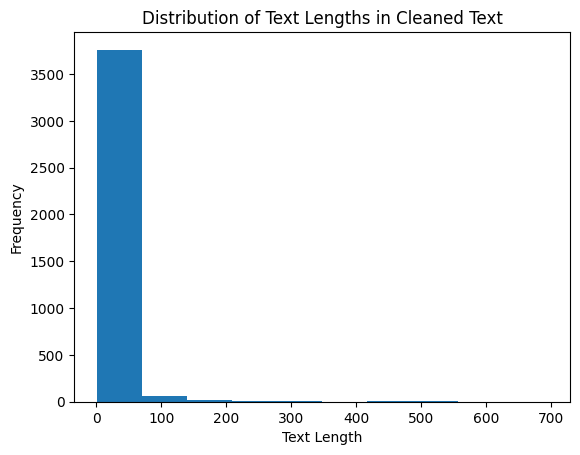

In [ ]:
text_lengths = df['clean_text_new'].str.split().str.len()
plt.hist(text_lengths)
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.title('Distribution of Text Lengths in Cleaned Text')
plt.show()

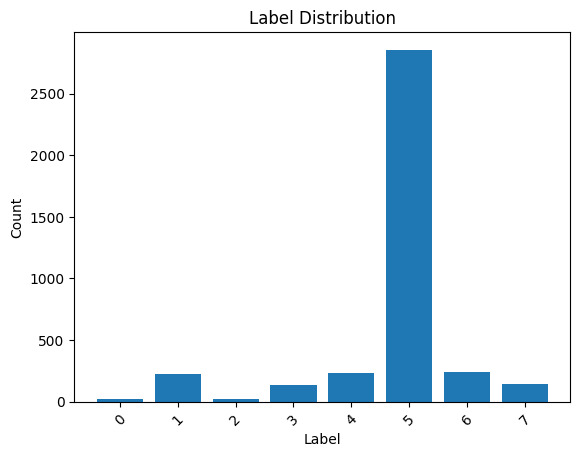

In [ ]:
label_counts = df['label_encode'].value_counts()

labels = label_counts.index.to_list()

plt.bar(labels, label_counts)
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df['label_encode'].value_counts()

label_encode
5    2857
6     243
4     228
1     224
7     139
3     131
0      23
2      19
Name: count, dtype: int64

## **SPLIT DATA**

// dataset e imbalance
sesok tak jajal e resampling karo augmentation

> Add blockquote



In [ ]:
aug = naw.ContextualWordEmbsAug(model_path='bert-base-multilingual-uncased', aug_p=0.1)
def augment_text(text):
    return aug.augment(text)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['clean_text_new'].values, df['label_encode'].values, test_size=0.15, random_state=42
)

## **AUGHMENTED TRAIN DATA**

In [ ]:
augmented_texts = []
augmented_labels = []
all_texts=df['clean_text_new'].values
all_labels=df['label_encode'].values

for text, label in zip(all_texts, all_labels):
    if label in [0,1,2,3,4,6,7]:
        augmented_texts.append(augment_text(text))
        augmented_labels.append(label)

In [ ]:
train_texts_augmented = np.concatenate((train_texts, np.concatenate(augmented_texts)))  # Flatten augmented_texts
train_labels_augmented = np.concatenate((train_labels, augmented_labels))

In [ ]:
train_texts = train_texts_augmented
train_labels = train_labels_augmented

In [ ]:
pd.Series(train_labels).value_counts()

5    2429
6     449
4     419
1     408
7     262
3     247
0      41
2      36
Name: count, dtype: int64

## **SAVE DATA**

In [ ]:
train_df_augmented = pd.DataFrame({'text': train_texts, 'label': train_labels})
train_df_augmented.to_csv('/content/drive/My Drive/BDC-SatriaData-2024/train_df_augmented.csv', index=False)

In [ ]:
train_data = pd.read_csv('/content/drive/My Drive/BDC-SatriaData-2024/train_df_augmented.csv')
train_data .head()

,text,label
0,jogetjoget menyenangkan tapi masalah pemuda me...,5
1,saya rasa emang selama ini kampanye bapak kura...,6
2,prabowo pionir perubahan dengan kemanusiaan se...,5
3,saudara jangan lupa tanggal februari kita cobl...,5
4,persen petani indonesia adalah petani gurem ya...,5


In [ ]:
train_texts = train_data['text'].values
train_labels = train_data['label'].values

In [ ]:
train_texts.shape

(4291,)

In [ ]:
train_labels.shape

(4291,)

// ROS

In [ ]:
#ros = RandomOverSampler(sampling_strategy='auto')
#train_texts = train_texts.reshape(-1, 1)
#train_texts, train_labels = ros.fit_resample(train_texts, train_labels)
#train_texts.shape

(16032, 1)

In [ ]:
#train_texts = train_texts.reshape(-1)
#train_texts.shape

(16032,)

## **BERT**

In [ ]:
#model_name='bert-base-uncased'
model_name='bert-base-multilingual-cased'
#model_name='indolem/indobert-base-uncased'

// coba pakai indobert atau mbert

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=512)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True, max_length=512)

In [ ]:
class ClassDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)  # Pastikan label menjadi Long
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = ClassDataset(train_encodings, train_labels)
test_dataset = ClassDataset(test_encodings, test_labels)

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(label_encoder.classes_))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device {device}.")

Using device cuda.


In [ ]:
class_counts = np.bincount(train_labels)
class_weights = 1. / class_counts
weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights, len(weights))

In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=6,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_steps=200,
    weight_decay=0.01,
    logging_dir='./logs',
    eval_steps=100,
    logging_steps=10,
    save_steps=100,
    load_best_model_at_end=True,
    evaluation_strategy='steps',
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
def compute_macro_metrics(predictions, labels):
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro')
    return precision, recall, f1

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    cm = confusion_matrix(labels, preds)
    macro_precision, macro_recall, macro_f1 = compute_macro_metrics(preds, labels)
    print(f'Macro Precision: {macro_precision:.4f}')
    print(f'Macro Recall: {macro_recall:.4f}')
    print(f'Macro F1-score: {macro_f1:.4f}')
    report = classification_report(labels, preds, target_names=label_encoder.classes_, digits=4)
    print(report)
    return {
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'macro_f1': macro_f1
    }

In [ ]:
class CustomTrainer(Trainer):
    def get_train_dataloader(self):
        class_counts = np.bincount(self.train_dataset.labels)
        class_weights = 1. / class_counts
        weights = class_weights[self.train_dataset.labels]
        sampler = WeightedRandomSampler(weights, len(weights))
        return DataLoader(
            self.train_dataset,
            batch_size=self.args.train_batch_size,
            sampler=sampler,
            collate_fn=self.data_collator,
        )

    def get_eval_dataloader(self, eval_dataset=None):
        eval_dataset = eval_dataset if eval_dataset is not None else self.eval_dataset
        return DataLoader(
            eval_dataset,
            batch_size=self.args.eval_batch_size,
            collate_fn=self.data_collator,
        )

In [ ]:
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

## **TRAINING**

In [ ]:
trainer.train()

Step,Training Loss,Validation Loss,Macro Precision,Macro Recall,Macro F1
100,1.287100,1.447420,0.352532,0.534578,0.326793
200,0.579300,1.258483,0.580139,0.798054,0.607507
300,0.490100,1.000079,0.528189,0.863579,0.608993
400,0.292200,1.353206,0.618185,0.883438,0.673980
500,0.224800,0.936187,0.681749,0.865886,0.714529
600,0.135300,0.919216,0.699389,0.910460,0.759045
700,0.081400,0.627632,0.776844,0.941768,0.839993
800,0.077800,0.715050,0.766493,0.943140,0.832738


Macro Precision: 0.3525
Macro Recall: 0.5346
Macro F1-score: 0.3268
                         precision    recall  f1-score   support

              Demografi     0.0755    0.8000    0.1379         5
                Ekonomi     0.4091    0.9000    0.5625        40
               Geografi     0.0435    0.5000    0.0800         2
               Ideologi     0.1860    0.5333    0.2759        15
Pertahanan dan Keamanan     0.4407    0.7027    0.5417        37
                Politik     0.9155    0.6075    0.7303       428
          Sosial Budaya     0.6667    0.1081    0.1860        37
       Sumber Daya Alam     0.0833    0.1250    0.1000        16

               accuracy                         0.5879       580
              macro avg     0.3525    0.5346    0.3268       580
           weighted avg     0.7823    0.5879    0.6355       580

Macro Precision: 0.5801
Macro Recall: 0.7981
Macro F1-score: 0.6075
                         precision    recall  f1-score   support

              D

TrainOutput(global_step=810, training_loss=0.4906245317724016, metrics={'train_runtime': 2719.1929, 'train_samples_per_second': 9.468, 'train_steps_per_second': 0.298, 'total_flos': 6774422160457728.0, 'train_loss': 0.4906245317724016, 'epoch': 6.0})

## **EVALUATE**

In [ ]:
results = trainer.evaluate()
print(results)

Macro Precision: 0.7768
Macro Recall: 0.9418
Macro F1-score: 0.8400
                         precision    recall  f1-score   support

              Demografi     1.0000    1.0000    1.0000         5
                Ekonomi     0.7660    0.9000    0.8276        40
               Geografi     1.0000    1.0000    1.0000         2
               Ideologi     0.6000    1.0000    0.7500        15
Pertahanan dan Keamanan     0.6102    0.9730    0.7500        37
                Politik     0.9753    0.8318    0.8979       428
          Sosial Budaya     0.6111    0.8919    0.7253        37
       Sumber Daya Alam     0.6522    0.9375    0.7692        16

               accuracy                         0.8586       580
              macro avg     0.7768    0.9418    0.8400       580
           weighted avg     0.8960    0.8586    0.8664       580

{'eval_loss': 0.6276315450668335, 'eval_macro_precision': 0.7768443035302436, 'eval_macro_recall': 0.9417675707249304, 'eval_macro_f1': 0.83999349294

In [ ]:
checkpoint_dir = './results/checkpoint-700'
model = AutoModelForSequenceClassification.from_pretrained(checkpoint_dir)
tokenizer = AutoTokenizer.from_pretrained(model_name)
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1

## **TEST DATA**

In [ ]:
data_test = pd.read_excel("/content/drive/MyDrive/BDC-SatriaData-2024/data_test_selection_normalized_baru.xlsx")

In [ ]:
data_test['text_clean'] = data_test['text_clean_normalized'].apply(clean_text)
data_test.head()

,IDText,Text,casefolding,cleaning,normalized,tokenize,normalized_2,text_clean_normalized,text_clean
0,TXT0001,Lu mau org2 pro-demokrasi di negara ini bisa p...,lu mau org2 pro-demokrasi di negara ini bisa p...,lu mau org prodemokrasi di negara ini bisa pun...,"['kamu', 'mau', 'orang', 'prodemokrasi', 'di',...","['lu', 'mau', 'org', 'prodemokrasi', 'di', 'ne...","['kamu', 'mau', 'orang', 'prodemokrasi', 'di',...",kamu mau orang prodemokrasi di negara ini bisa...,kamu mau orang prodemokrasi di negara ini bisa...
1,TXT0002,Prabowo ditanya soal hutang luar negeri dia me...,prabowo ditanya soal hutang luar negeri dia me...,prabowo ditanya soal hutang luar negeri dia me...,"['prabowo', 'ditanya', 'soal', 'hutang', 'luar...","['prabowo', 'ditanya', 'soal', 'hutang', 'luar...","['prabowo', 'ditanya', 'soal', 'hutang', 'luar...",prabowo ditanya soal hutang luar negeri dia me...,prabowo ditanya soal hutang luar negeri dia me...
2,TXT0003,kiki_daliyo Ganjar Pranowo itulah beliau soso...,kiki_daliyo ganjar pranowo itulah beliau soso...,kikidaliyo ganjar pranowo itulah beliau sosok ...,"['kikidaliyo', 'ganjar', 'pranowo', 'itulah', ...","['kikidaliyo', 'ganjar', 'pranowo', 'itulah', ...","['kikidaliyo', 'ganjar', 'pranowo', 'itulah', ...",kikidaliyo ganjar pranowo itulah beliau sosok ...,kikidaliyo ganjar pranowo itulah beliau sosok ...
3,TXT0004,@kumparan Prabowo Gibran yang bisa melakukan i...,@kumparan prabowo gibran yang bisa melakukan i...,prabowo gibran yang bisa melakukan itu semua d...,"['prabowo', 'gibran', 'yang', 'bisa', 'melakuk...","['prabowo', 'gibran', 'yang', 'bisa', 'melakuk...","['prabowo', 'gibran', 'yang', 'bisa', 'melakuk...",prabowo gibran yang bisa melakukan itu semua d...,prabowo gibran yang bisa melakukan itu semua d...
4,TXT0005,@sniperruben45 @uda_zulhendra @ainunnajib Lah ...,@sniperruben45 @uda_zulhendra @ainunnajib lah ...,lah justru yg gak nyambung junjungan elu aomkm...,"['lah', 'justru', 'yang', 'gak', 'sambung', 'j...","['lah', 'justru', 'yg', 'gak', 'nyambung', 'ju...","['lah', 'justru', 'yang', 'gak', 'sambung', 'j...",lah justru yang gak sambung junjungan kamu aom...,lah justru yang gak sambung junjungan kamu aom...


In [ ]:
print(data_test['text_clean'].str.split().str.len().max())
print(data_test['text_clean'].str.split().str.len().min())

525
3


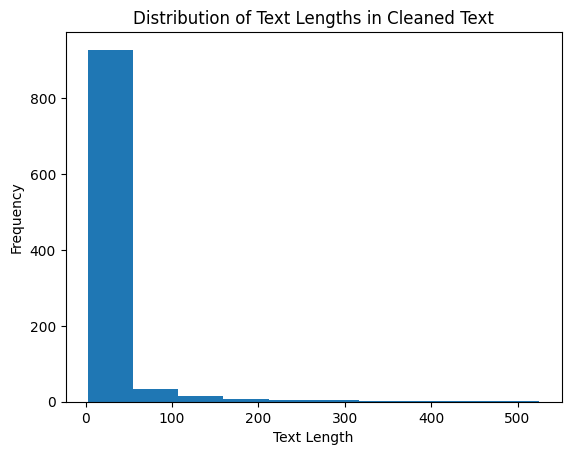

In [ ]:
text_lengths = data_test['text_clean'].str.split().str.len()
plt.hist(text_lengths)
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.title('Distribution of Text Lengths in Cleaned Text')
plt.show()

## **PREDICTION**

In [ ]:
def predict(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding='max_length', max_length=512)

    inputs = {key: tensor.to(device) for key, tensor in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits

    prediction = torch.argmax(logits, dim=1).item()
    return label_encoder.inverse_transform([prediction])[0]

In [ ]:
data_test['predict'] = data_test['text_clean'].apply(predict)

In [ ]:
data_test.head()

,IDText,Text,casefolding,cleaning,normalized,tokenize,normalized_2,text_clean_normalized,text_clean,predict
0,TXT0001,Lu mau org2 pro-demokrasi di negara ini bisa p...,lu mau org2 pro-demokrasi di negara ini bisa p...,lu mau org prodemokrasi di negara ini bisa pun...,"['kamu', 'mau', 'orang', 'prodemokrasi', 'di',...","['lu', 'mau', 'org', 'prodemokrasi', 'di', 'ne...","['kamu', 'mau', 'orang', 'prodemokrasi', 'di',...",kamu mau orang prodemokrasi di negara ini bisa...,kamu mau orang prodemokrasi di negara ini bisa...,Politik
1,TXT0002,Prabowo ditanya soal hutang luar negeri dia me...,prabowo ditanya soal hutang luar negeri dia me...,prabowo ditanya soal hutang luar negeri dia me...,"['prabowo', 'ditanya', 'soal', 'hutang', 'luar...","['prabowo', 'ditanya', 'soal', 'hutang', 'luar...","['prabowo', 'ditanya', 'soal', 'hutang', 'luar...",prabowo ditanya soal hutang luar negeri dia me...,prabowo ditanya soal hutang luar negeri dia me...,Ekonomi
2,TXT0003,kiki_daliyo Ganjar Pranowo itulah beliau soso...,kiki_daliyo ganjar pranowo itulah beliau soso...,kikidaliyo ganjar pranowo itulah beliau sosok ...,"['kikidaliyo', 'ganjar', 'pranowo', 'itulah', ...","['kikidaliyo', 'ganjar', 'pranowo', 'itulah', ...","['kikidaliyo', 'ganjar', 'pranowo', 'itulah', ...",kikidaliyo ganjar pranowo itulah beliau sosok ...,kikidaliyo ganjar pranowo itulah beliau sosok ...,Ideologi
3,TXT0004,@kumparan Prabowo Gibran yang bisa melakukan i...,@kumparan prabowo gibran yang bisa melakukan i...,prabowo gibran yang bisa melakukan itu semua d...,"['prabowo', 'gibran', 'yang', 'bisa', 'melakuk...","['prabowo', 'gibran', 'yang', 'bisa', 'melakuk...","['prabowo', 'gibran', 'yang', 'bisa', 'melakuk...",prabowo gibran yang bisa melakukan itu semua d...,prabowo gibran yang bisa melakukan itu semua d...,Politik
4,TXT0005,@sniperruben45 @uda_zulhendra @ainunnajib Lah ...,@sniperruben45 @uda_zulhendra @ainunnajib lah ...,lah justru yg gak nyambung junjungan elu aomkm...,"['lah', 'justru', 'yang', 'gak', 'sambung', 'j...","['lah', 'justru', 'yg', 'gak', 'nyambung', 'ju...","['lah', 'justru', 'yang', 'gak', 'sambung', 'j...",lah justru yang gak sambung junjungan kamu aom...,lah justru yang gak sambung junjungan kamu aom...,Ekonomi


In [ ]:
data_test['Text'][1]

'Prabowo ditanya soal hutang luar negeri dia menjawab hutang luar negeri Indonesia masih terhitung rendah dan dia tak khawatir intervensi asing akibat hutang seperti krisis moneter 1997 saat Orde Baru.\n\nDibantah Ganjar hutang luar negeri demi infrastruktur bisa berbahaya. \n(BTW bajunya Ganjar matching dengan tema debat)\n\nAnies menegaskan normal hutang luar negeri yg aman tak lebih dari 30% GDP. Hutang dipakai Menhan membeli alutsista bekas adalah suatu kesia-siaan.\n\nPrabowo tak merespon soal alutsista bekas karena jika membeli baru uang yg dikeluarkan lebih besar. [RE mazzini_gsp]'

In [ ]:
data_test['text_clean'][1]

'prabowo ditanya soal hutang luar negeri dia menjawab hutang luar negeri indonesia masih terhitung rendah dan dia tak khawatir intervensi asing akibat hutang seperti krisis moneter saat orde baru dibantah ganjar hutang luar negeri demi infrastruktur bisa berbahaya btw bajunya ganjar matching dengan tema debat anies menegaskan normal hutang luar negeri yang aman tak lebih dari gdp hutang dipakai menhan membeli alutsista bekas adalah suatu kesiasiaan prabowo tak merespon soal alutsista bekas karena jika membeli baru uang yang dikeluarkan lebih besar'

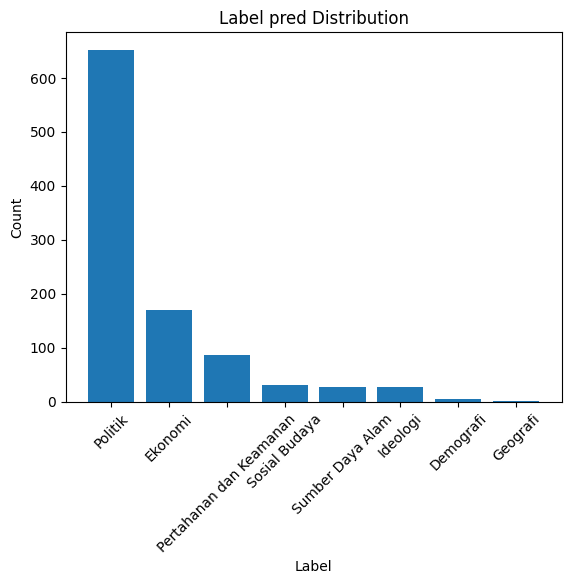

In [ ]:
label_counts = data_test['predict'].value_counts()

labels = label_counts.index.to_list()

plt.bar(labels, label_counts)
plt.title('Label pred Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

//resample

In [ ]:
data_test['predict'].value_counts()

predict
Politik                    652
Ekonomi                    169
Pertahanan dan Keamanan     87
Sosial Budaya               31
Sumber Daya Alam            28
Ideologi                    27
Demografi                    4
Geografi                     2
Name: count, dtype: int64

// prediksi lama

In [ ]:
data_test.head()

,IDText,Text,casefolding,cleaning,normalized,tokenize,normalized_2,text_clean_normalized,text_clean,predict
0,TXT0001,Lu mau org2 pro-demokrasi di negara ini bisa p...,lu mau org2 pro-demokrasi di negara ini bisa p...,lu mau org prodemokrasi di negara ini bisa pun...,"['kamu', 'mau', 'orang', 'prodemokrasi', 'di',...","['lu', 'mau', 'org', 'prodemokrasi', 'di', 'ne...","['kamu', 'mau', 'orang', 'prodemokrasi', 'di',...",kamu mau orang prodemokrasi di negara ini bisa...,kamu mau orang prodemokrasi di negara ini bisa...,Politik
1,TXT0002,Prabowo ditanya soal hutang luar negeri dia me...,prabowo ditanya soal hutang luar negeri dia me...,prabowo ditanya soal hutang luar negeri dia me...,"['prabowo', 'ditanya', 'soal', 'hutang', 'luar...","['prabowo', 'ditanya', 'soal', 'hutang', 'luar...","['prabowo', 'ditanya', 'soal', 'hutang', 'luar...",prabowo ditanya soal hutang luar negeri dia me...,prabowo ditanya soal hutang luar negeri dia me...,Ekonomi
2,TXT0003,kiki_daliyo Ganjar Pranowo itulah beliau soso...,kiki_daliyo ganjar pranowo itulah beliau soso...,kikidaliyo ganjar pranowo itulah beliau sosok ...,"['kikidaliyo', 'ganjar', 'pranowo', 'itulah', ...","['kikidaliyo', 'ganjar', 'pranowo', 'itulah', ...","['kikidaliyo', 'ganjar', 'pranowo', 'itulah', ...",kikidaliyo ganjar pranowo itulah beliau sosok ...,kikidaliyo ganjar pranowo itulah beliau sosok ...,Ideologi
3,TXT0004,@kumparan Prabowo Gibran yang bisa melakukan i...,@kumparan prabowo gibran yang bisa melakukan i...,prabowo gibran yang bisa melakukan itu semua d...,"['prabowo', 'gibran', 'yang', 'bisa', 'melakuk...","['prabowo', 'gibran', 'yang', 'bisa', 'melakuk...","['prabowo', 'gibran', 'yang', 'bisa', 'melakuk...",prabowo gibran yang bisa melakukan itu semua d...,prabowo gibran yang bisa melakukan itu semua d...,Politik
4,TXT0005,@sniperruben45 @uda_zulhendra @ainunnajib Lah ...,@sniperruben45 @uda_zulhendra @ainunnajib lah ...,lah justru yg gak nyambung junjungan elu aomkm...,"['lah', 'justru', 'yang', 'gak', 'sambung', 'j...","['lah', 'justru', 'yg', 'gak', 'nyambung', 'ju...","['lah', 'justru', 'yang', 'gak', 'sambung', 'j...",lah justru yang gak sambung junjungan kamu aom...,lah justru yang gak sambung junjungan kamu aom...,Ekonomi


In [ ]:
data_test[['IDText', 'predict']].to_csv('/content/drive/MyDrive/BDC-SatriaData-2024/prediction.csv', index=False)